# Exploratory Data Analysis (EDA)

## Objective

Understand the structure of the stock dataset before feature engineering.

Dataset:
RELIANCE_NS.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
BASE_DIR = Path.cwd().parent

DATA_PATH = BASE_DIR / "data" / "raw" / "RELIANCE_NS.csv"

df = pd.read_csv(DATA_PATH)

In [3]:
df.head()

,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-07-06,962.3599853515625,980.5948486328125,991.7169799804688,978.4719848632812,989.8941040039062,10070124
3,2021-07-07,955.679443359375,973.7877197265625,981.956298828125,968.2266845703125,981.956298828125,10454892
4,2021-07-08,947.7760009765625,965.7345581054688,976.9721069335938,960.3811645507812,976.9721069335938,11185460


In [4]:
df.shape

(1240, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1240 non-null   str  
 1   Adj Close  1239 non-null   str  
 2   Close      1239 non-null   str  
 3   High       1239 non-null   str  
 4   Low        1239 non-null   str  
 5   Open       1239 non-null   str  
 6   Volume     1239 non-null   str  
dtypes: str(7)
memory usage: 67.9 KB


In [6]:
df.describe()

,Price,Adj Close,Close,High,Low,Open,Volume
count,1240,1239,1239,1239,1239,1239,1239
unique,1240,1203,1183,1132,1136,1058,1235
top,Ticker,1267.2559814453125,1464.824951171875,1306.0,1151.442138671875,1420.0,0
freq,1,3,4,4,4,6,5


In [7]:
df.columns

Index(['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

## EDA Part 2 — Price and Volume Trend Analysis

### Objective

Understand the historical behaviour of each stock's closing price, adjusted closing price, and trading volume through visual trend analysis.

This section uses the cleaned datasets from `ml/data/interim/` (produced by `clean_data.py`) rather than the raw files, so all stocks share a consistent, standardized schema.


In [8]:
BASE_DIR = Path.cwd().parent
INTERIM_DATA_DIR = BASE_DIR / "data" / "interim"
FIGURES_DIR = BASE_DIR / "reports" / "figures"

stock_data = {}

for filepath in sorted(INTERIM_DATA_DIR.glob("*.csv")):
    ticker = filepath.stem
    stock_data[ticker] = pd.read_csv(filepath, parse_dates=["Date"])

list(stock_data.keys())


['BHARTIARTL_NS',
 'HDFCBANK_NS',
 'ICICIBANK_NS',
 'INFY_NS',
 'ITC_NS',
 'LT_NS',
 'RELIANCE_NS',
 'SBIN_NS',
 'TCS_NS',
 'WIPRO_NS']

### 1. Closing Price Trend

**Objective:** Plot the Closing Price of every stock over time on a single figure.

**Why this visualization is useful:** A shared closing-price timeline makes it possible to see each stock's overall price trajectory at a glance and compare how different stocks have moved relative to one another over the same period.


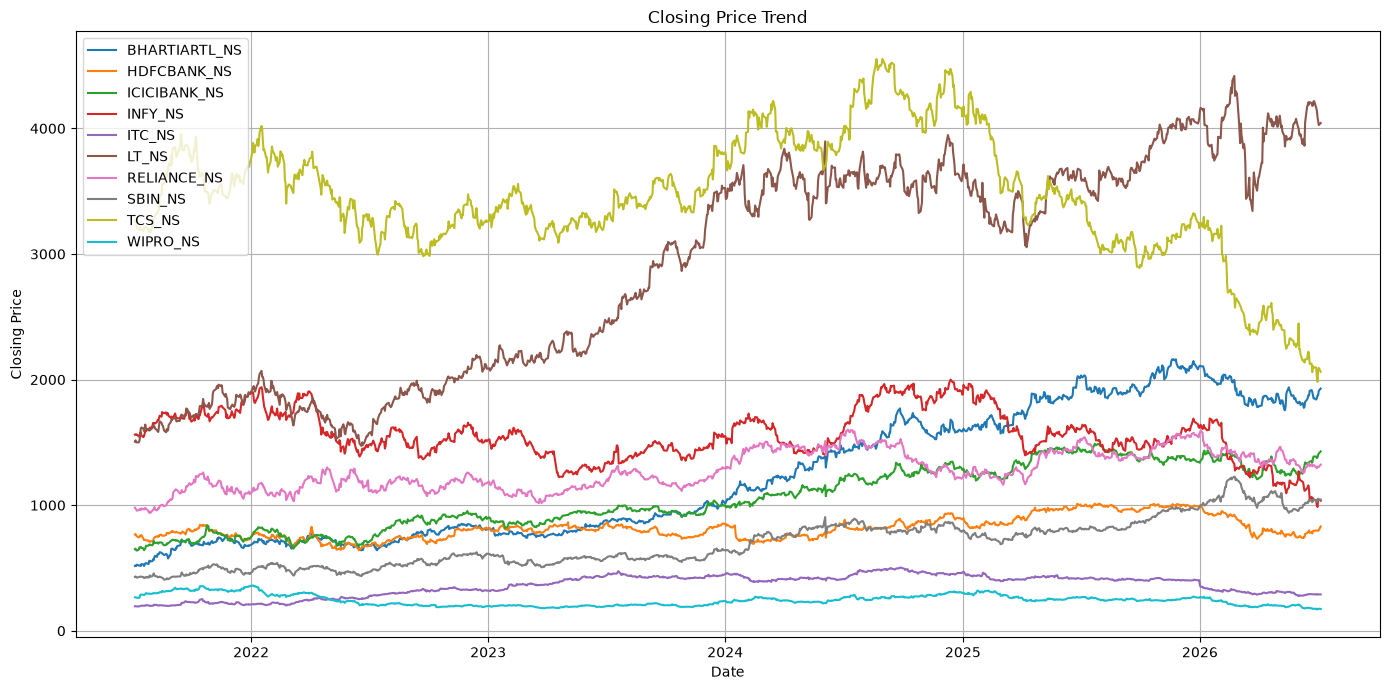

In [9]:
plt.figure(figsize=(14, 7))

for ticker, df in stock_data.items():
    plt.plot(df["Date"], df["Close"], label=ticker)

plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "closing_price_trend.png")
plt.show()


### 2. Adjusted Closing Price Trend

**Objective:** Plot the Adjusted Closing Price of every stock over time on a single figure.

**Why this visualization is useful:** Adjusted Close accounts for corporate actions such as dividends and stock splits, so plotting it alongside the raw Closing Price provides a more consistent basis for comparing long-term price trends across stocks.


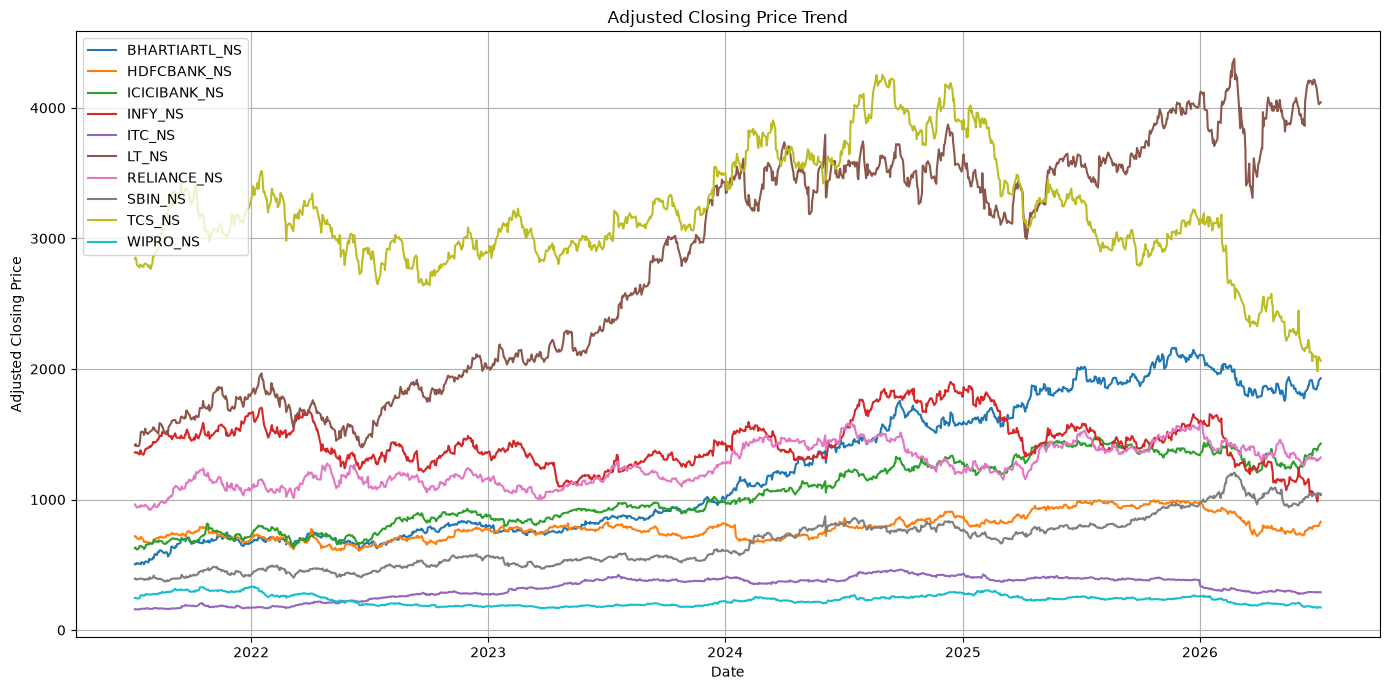

In [10]:
plt.figure(figsize=(14, 7))

for ticker, df in stock_data.items():
    plt.plot(df["Date"], df["Adj Close"], label=ticker)

plt.title("Adjusted Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "adjusted_close_trend.png")
plt.show()


### 3. Trading Volume Trend

**Objective:** Plot the Trading Volume of every stock over time on a single figure.

**Why this visualization is useful:** Volume reflects trading activity and liquidity; viewing it across all stocks on a shared timeline highlights how active each stock has been and lays the groundwork for later liquidity- or activity-based analysis.


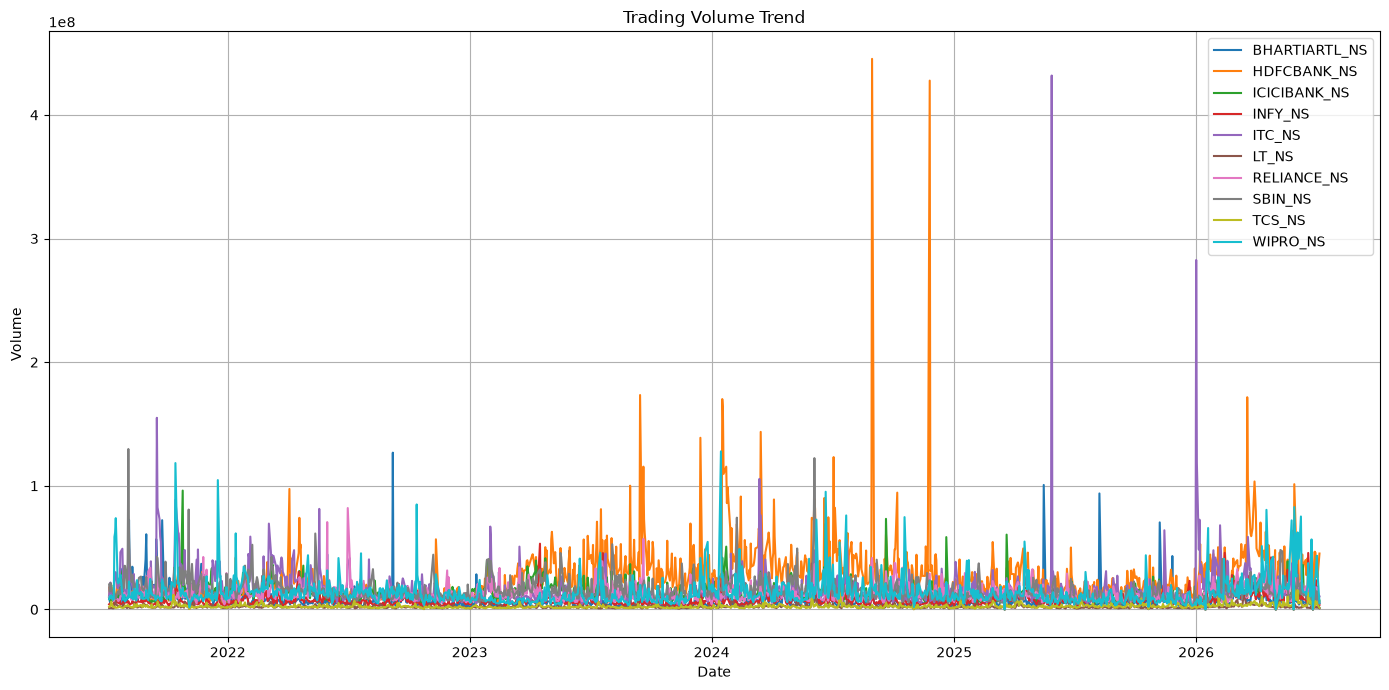

In [11]:
plt.figure(figsize=(14, 7))

for ticker, df in stock_data.items():
    plt.plot(df["Date"], df["Volume"], label=ticker)

plt.title("Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "volume_trend.png")
plt.show()


## EDA Part 3 — Statistical Exploratory Analysis

### Objective

Perform statistical exploratory analysis on the cleaned stock data to understand return behaviour, volatility, and cross-stock relationships. This will inform later Feature Engineering and ML Model Development.

This section builds a combined Adjusted Close price table (all stocks, aligned by Date) from `stock_data`, which was loaded in EDA Part 2 from `ml/data/interim/`.


In [12]:
import numpy as np

adj_close_df = pd.DataFrame(
    {ticker: df.set_index("Date")["Adj Close"] for ticker, df in stock_data.items()}
)

adj_close_df.head()


,BHARTIARTL_NS,HDFCBANK_NS,ICICIBANK_NS,INFY_NS,ITC_NS,LT_NS,RELIANCE_NS,SBIN_NS,TCS_NS,WIPRO_NS
Date,,,,,,,,,,
2021-07-06,504.713043,718.084106,628.962097,1360.633179,159.446518,1414.813843,962.359985,393.112671,2843.288330,246.034317
2021-07-07,508.070770,720.330078,632.540649,1362.723511,160.430771,1425.104126,955.679443,395.948334,2854.314209,245.826492
2021-07-08,503.945557,711.416504,620.837769,1359.370239,159.052811,1410.303101,947.776001,388.264435,2839.976562,245.295197
2021-07-09,514.450378,702.783813,617.597595,1361.243042,158.541031,1409.269287,938.083618,387.624115,2796.093750,242.893112
2021-07-12,508.118744,695.765381,625.044922,1348.134644,158.344177,1410.350098,943.926208,391.008698,2782.976562,242.916214


### 1. Daily Return

**Objective:** Calculate the daily percentage return of each stock's Adjusted Close price and plot all stocks on one figure.

**Why this analysis is important:** Daily returns normalize price changes into a comparable scale across stocks of different price levels, forming the basis for most downstream return, volatility, and risk calculations.


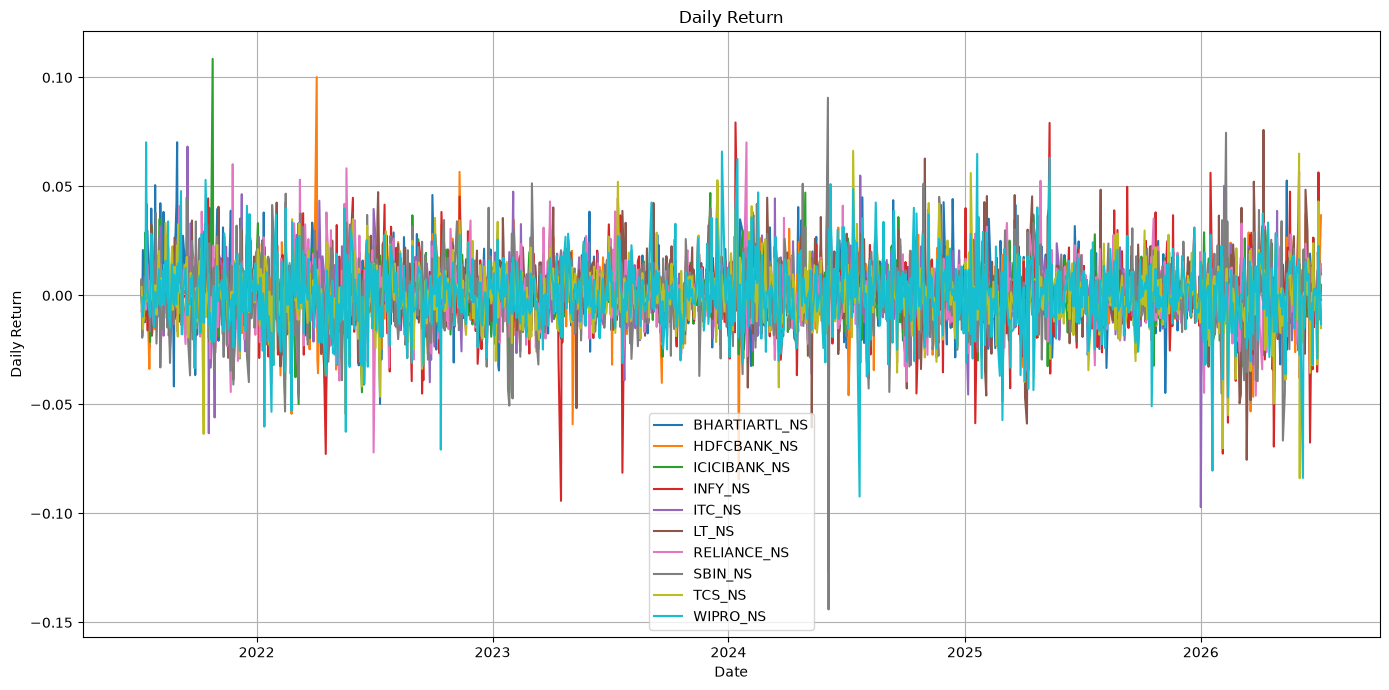

In [13]:
daily_return_df = adj_close_df.pct_change()

plt.figure(figsize=(14, 7))

for ticker in daily_return_df.columns:
    plt.plot(daily_return_df.index, daily_return_df[ticker], label=ticker)

plt.title("Daily Return")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "daily_return.png")
plt.show()


### 2. Cumulative Return

**Objective:** Calculate the cumulative return of each stock using `(1 + daily_return).cumprod()` and plot all stocks on one figure.

**Why this analysis is important:** Cumulative return shows the growth of an initial investment over the full time period, making long-term performance differences between stocks easier to see than daily returns alone.


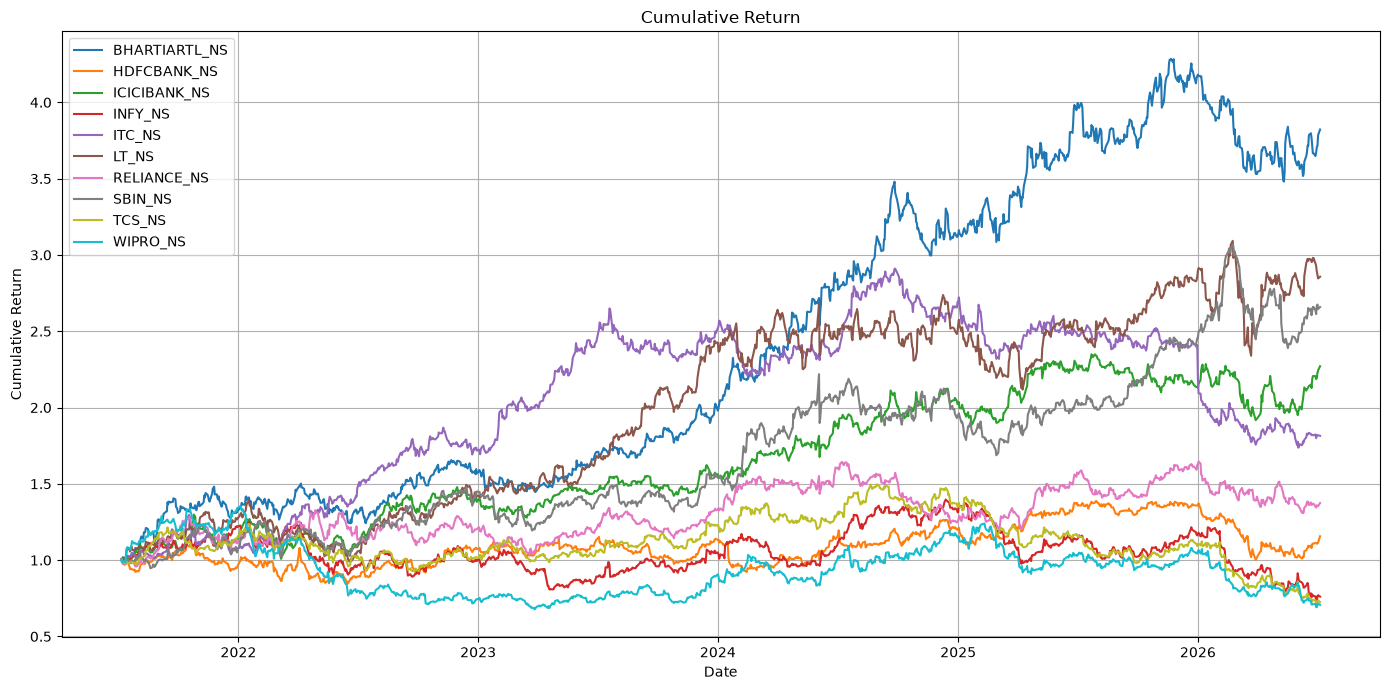

In [14]:
cumulative_return_df = (1 + daily_return_df).cumprod()

plt.figure(figsize=(14, 7))

for ticker in cumulative_return_df.columns:
    plt.plot(cumulative_return_df.index, cumulative_return_df[ticker], label=ticker)

plt.title("Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "cumulative_return.png")
plt.show()


### 3. Rolling Volatility

**Objective:** Calculate the 30-day rolling standard deviation of daily returns for each stock and plot all stocks on one figure.

**Why this analysis is important:** Rolling volatility captures how a stock's risk level changes over time, rather than assuming risk is constant across the full history, which is relevant for later risk classification work.


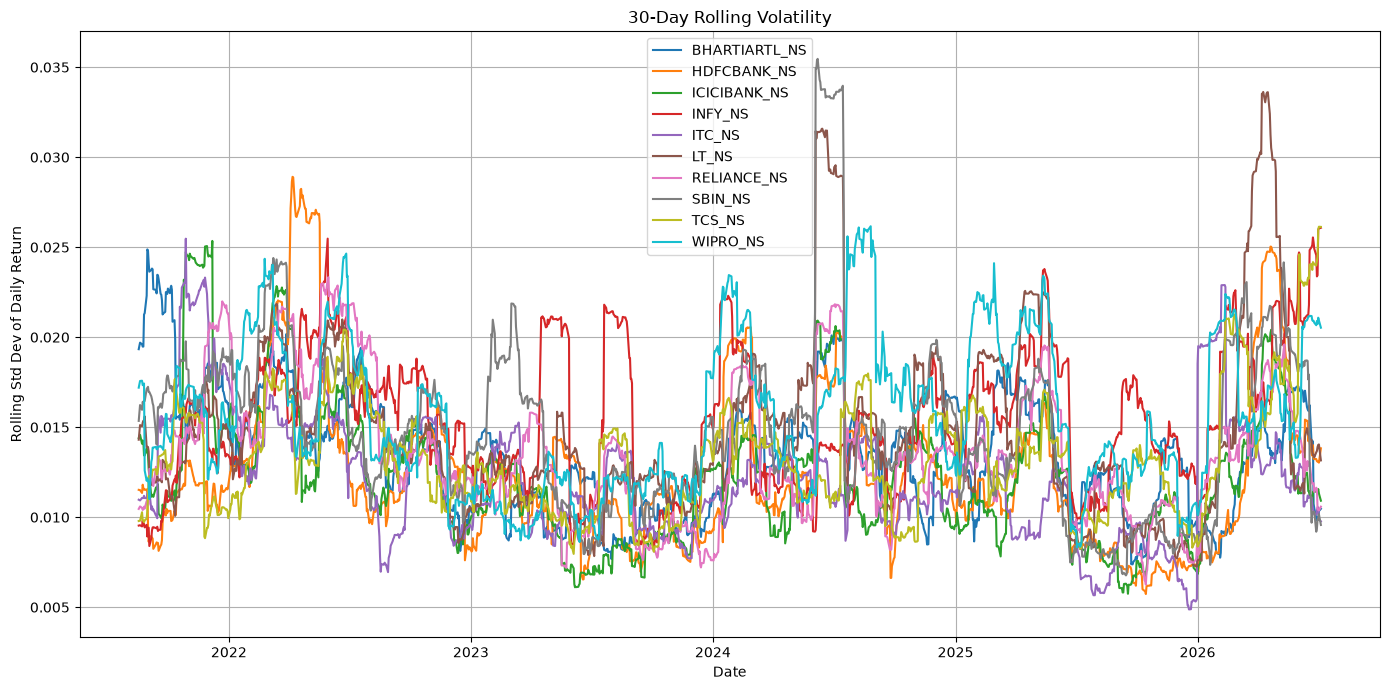

In [15]:
rolling_volatility_df = daily_return_df.rolling(window=30).std()

plt.figure(figsize=(14, 7))

for ticker in rolling_volatility_df.columns:
    plt.plot(rolling_volatility_df.index, rolling_volatility_df[ticker], label=ticker)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Std Dev of Daily Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "rolling_volatility.png")
plt.show()


### 4. Correlation Heatmap

**Objective:** Build a DataFrame of Adjusted Close prices for all stocks, calculate the correlation matrix, and plot it as a heatmap using matplotlib only.

**Why this analysis is important:** Correlation between stocks indicates how closely their prices move together, which is useful context for later portfolio construction and diversification considerations.


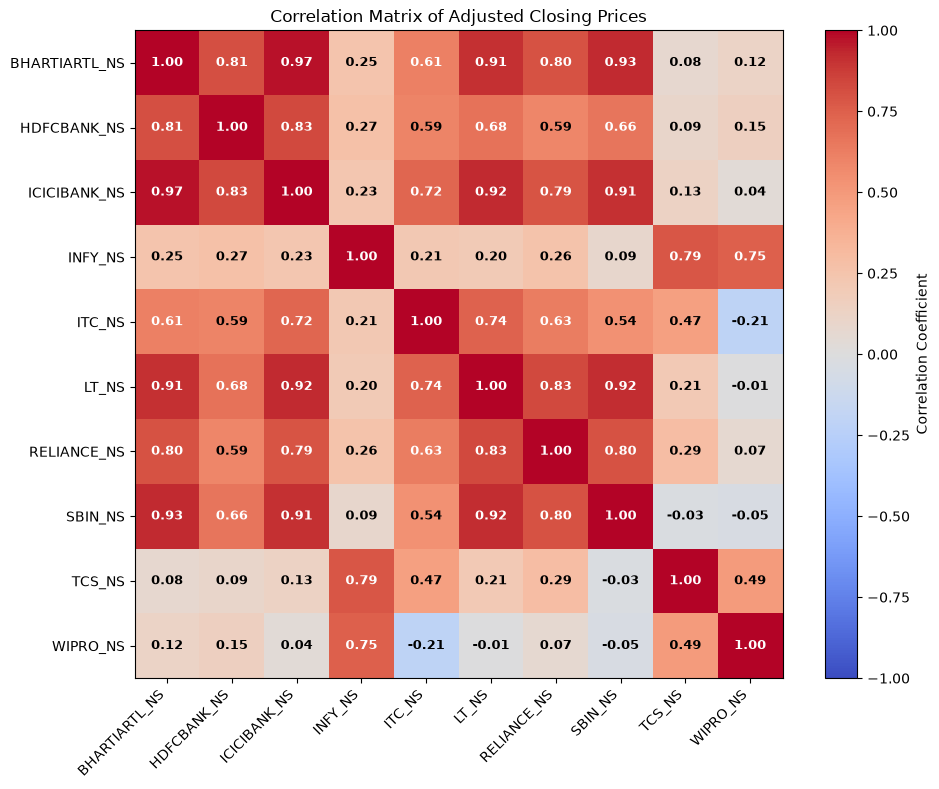

In [16]:
correlation_matrix = adj_close_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

# Tick positions
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

# Tick labels
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.columns)

# Write correlation coefficient inside each cell
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]

        # Better text color depending on background
        text_color = "white" if abs(value) > 0.6 else "black"

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9,
            fontweight="bold"
        )

fig.colorbar(im, ax=ax, label="Correlation Coefficient")

ax.set_title("Correlation Matrix of Adjusted Closing Prices")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5. Distribution of Daily Returns

**Objective:** Plot a histogram of the daily returns for each stock.

**Why this analysis is important:** The shape of the return distribution (e.g. how spread out or symmetric it is) is a standard input into risk and modeling assumptions used in later stages of the pipeline.


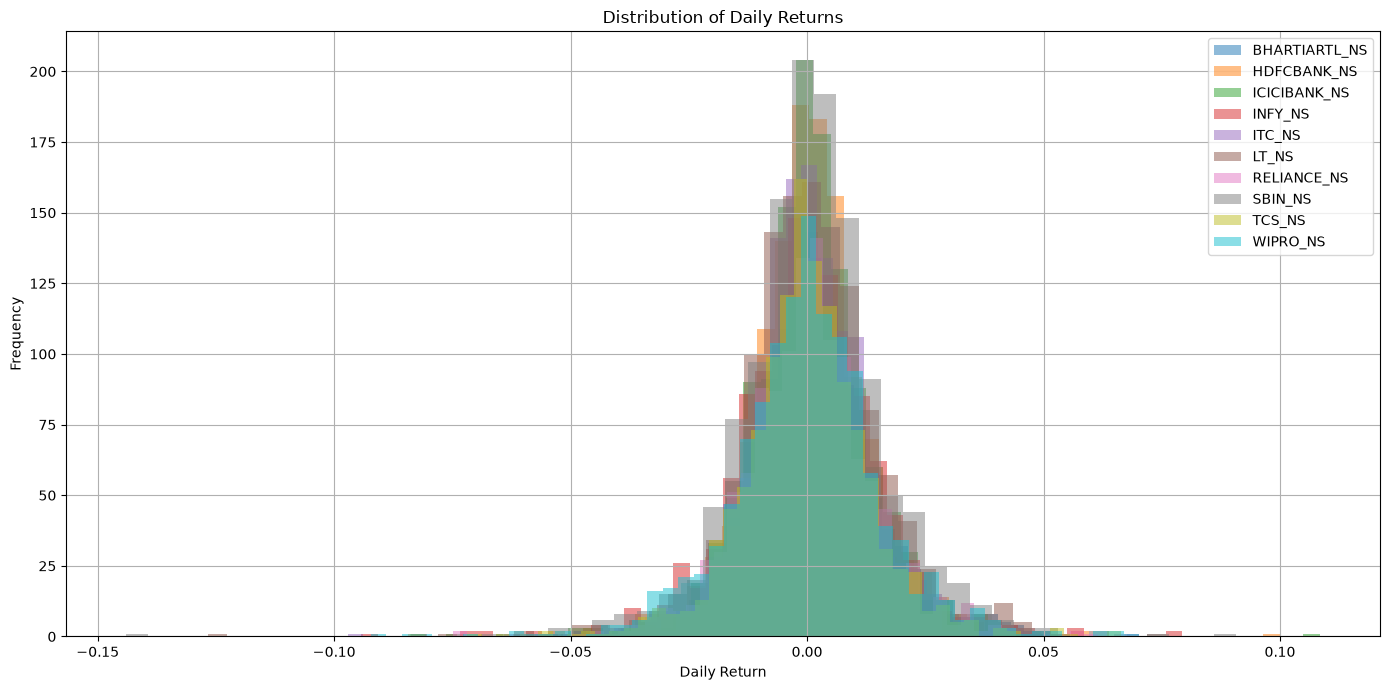

In [17]:
plt.figure(figsize=(14, 7))

for ticker in daily_return_df.columns:
    plt.hist(daily_return_df[ticker].dropna(), bins=50, alpha=0.5, label=ticker)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "daily_return_distribution.png")
plt.show()


### 6. Boxplot of Daily Returns

**Objective:** Plot a boxplot comparing the distribution of daily returns across all stocks.

**Why this analysis is important:** Boxplots summarize spread and extreme values (outliers) per stock side by side, complementing the histogram view in section 5 with an easier stock-to-stock comparison.


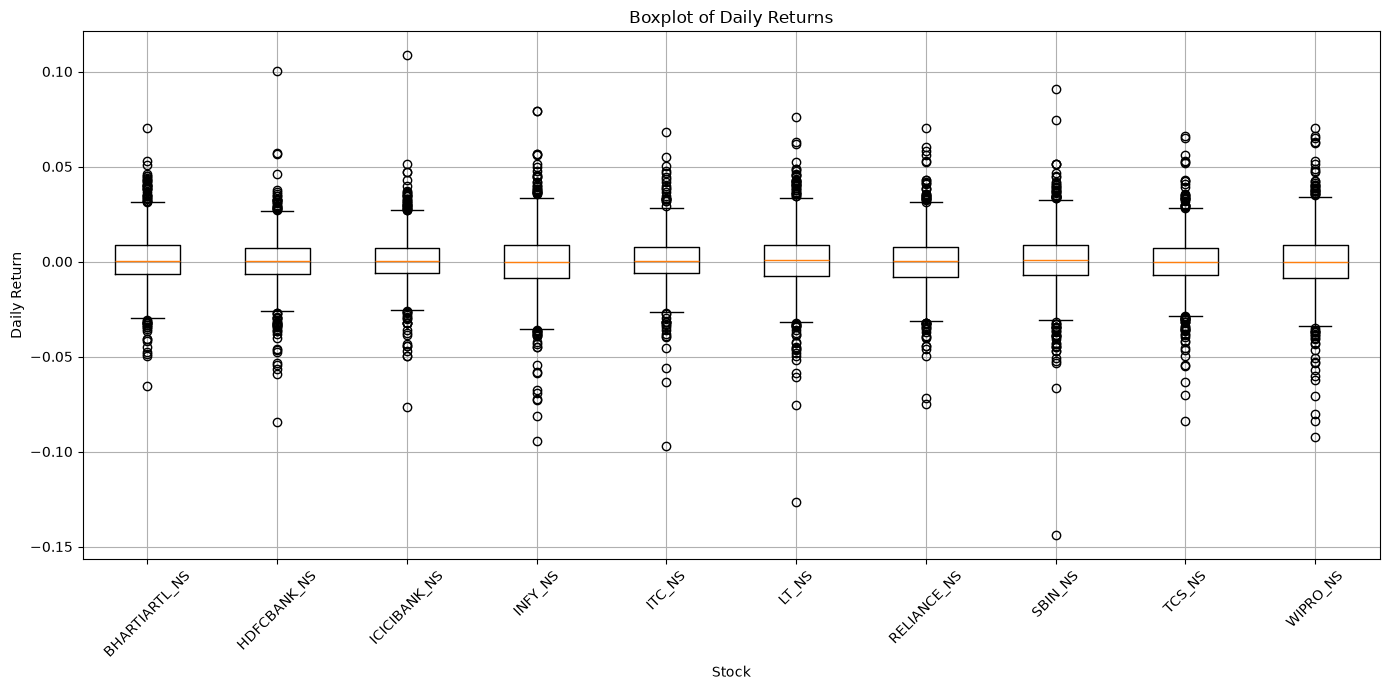

In [18]:
plt.figure(figsize=(14, 7))

plt.boxplot(
    [daily_return_df[ticker].dropna() for ticker in daily_return_df.columns],
    tick_labels=daily_return_df.columns,
)

plt.title("Boxplot of Daily Returns")
plt.xlabel("Stock")
plt.ylabel("Daily Return")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "daily_return_boxplot.png")
plt.show()


### 7. Risk vs Return Scatter Plot

**Objective:** Plot each stock's annualized volatility (x-axis) against its annualized return (y-axis), with every point labeled by ticker.

**Why this analysis is important:** Positioning stocks on a risk-return plane is a standard way to view the trade-off between the two, and is directly useful context for later risk classification.


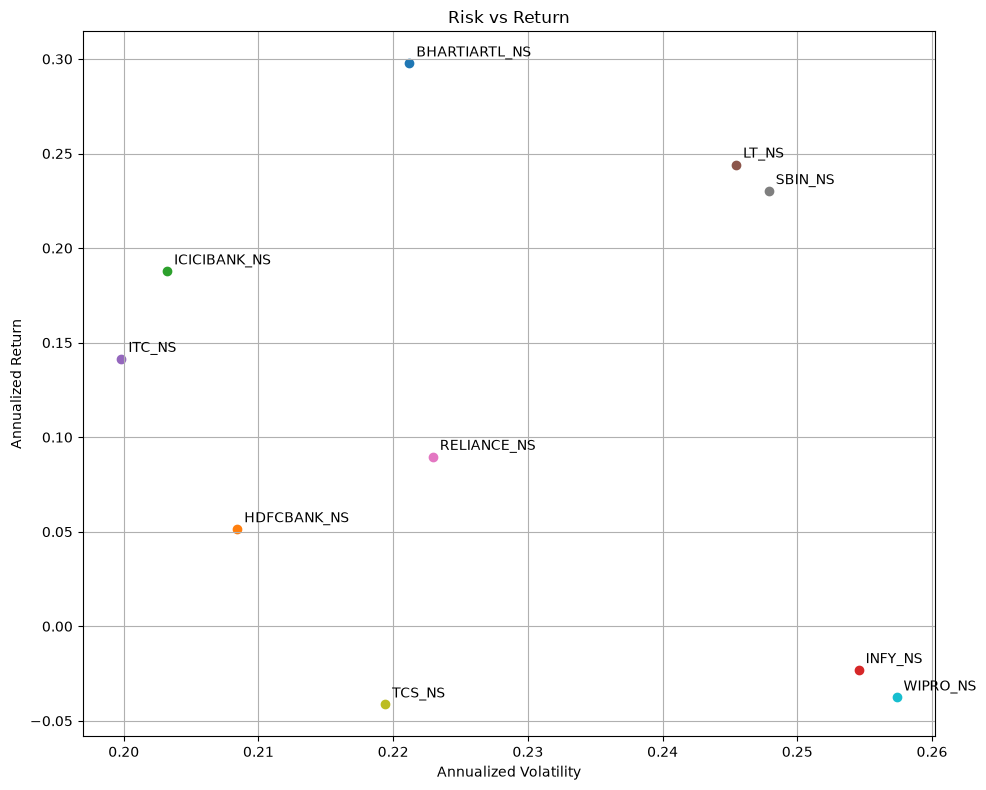

In [19]:
TRADING_DAYS_PER_YEAR = 252

annualized_return = daily_return_df.mean() * TRADING_DAYS_PER_YEAR
annualized_volatility = daily_return_df.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

plt.figure(figsize=(10, 8))

for ticker in daily_return_df.columns:
    x = annualized_volatility[ticker]
    y = annualized_return[ticker]
    plt.scatter(x, y)
    plt.annotate(ticker, (x, y), textcoords="offset points", xytext=(5, 5))

plt.title("Risk vs Return")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "risk_return_scatter.png")
plt.show()
